In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.facecolor'] = 'f8f9fa'
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB




# **Fraud Detection**
Goal: Detect fraudulent transactions (highly imbalanced data)

In [2]:
#load dataset

data3 = pd.read_csv('/content/question3_fraud_detection.csv')

# Basic exploration
print("Dataset Info:")
print(data3.info())
print("\nDataset Description:")
print(data3.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_amount           50000 non-null  float64
 1   merchant_category            50000 non-null  int64  
 2   transaction_hour             50000 non-null  int64  
 3   day_of_week                  50000 non-null  int64  
 4   is_weekend                   50000 non-null  int64  
 5   customer_age                 50000 non-null  int64  
 6   account_age_days             50000 non-null  int64  
 7   previous_transactions_day    50000 non-null  int64  
 8   average_transaction_amount   50000 non-null  float64
 9   credit_limit                 50000 non-null  float64
 10  amount_vs_average_ratio      50000 non-null  float64
 11  time_since_last_transaction  50000 non-null  float64
 12  location_risk_score          50000 non-null  float64
 13  is

Data is loaded and explored above to view all features, data types, count and to gather basic stats.

In [3]:
fraud_rate = data3['is_fraud'].mean()
print("Fraud Rate:", fraud_rate)

Fraud Rate: 0.00296


The mean was used to give a rate of fraud, which was identified as the target column.

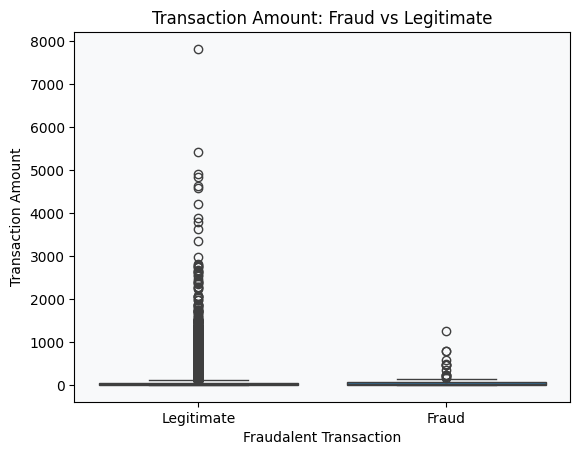

In [4]:
#Transaction Pattern based off amount

sns.boxplot(x='is_fraud', y='transaction_amount', data=data3)

plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.title('Transaction Amount: Fraud vs Legitimate')
plt.xlabel('Fraudalent Transaction')
plt.ylabel('Transaction Amount')
plt.show()

This code creates a boxplot to compare transaction amounts between legitimate and fraudulent transactions. It helps visualize differences in distribution and identify whether fraud cases tend to involve higher or more variable transaction amounts.

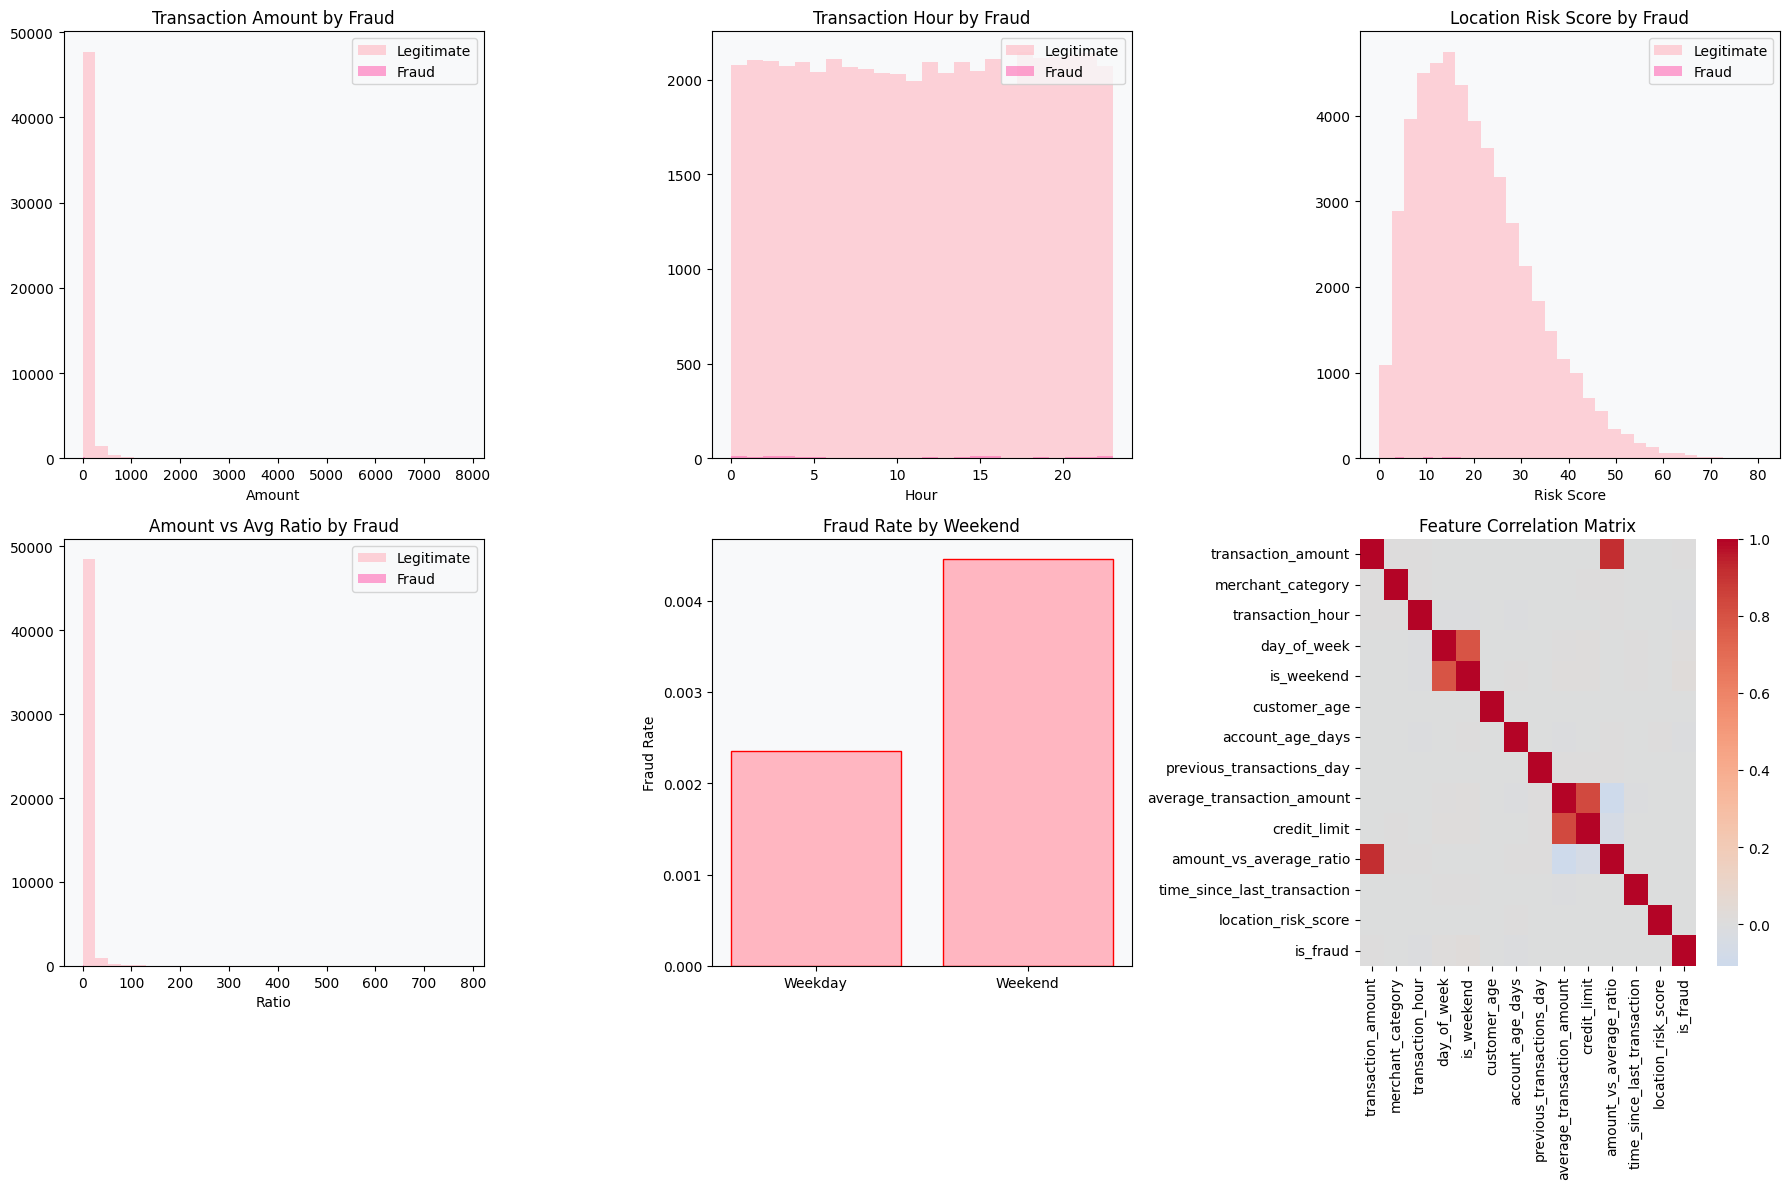

In [5]:
#Additional Transaction Patterns

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Transaction Amount
axes[0, 0].hist(data3[data3['is_fraud'] == 0]['transaction_amount'],
                alpha=0.6, label='Legitimate', bins=30, color="#ffb6c1")
axes[0, 0].hist(data3[data3['is_fraud'] == 1]['transaction_amount'],
                alpha=0.6, label='Fraud', bins=30, color="#ff69b4")
axes[0, 0].set_title('Transaction Amount by Fraud')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].legend()

# 2. Transaction Hour
axes[0, 1].hist(data3[data3['is_fraud'] == 0]['transaction_hour'],
                alpha=0.6, label='Legitimate', bins=24, color="#ffb6c1")
axes[0, 1].hist(data3[data3['is_fraud'] == 1]['transaction_hour'],
                alpha=0.6, label='Fraud', bins=24, color="#ff69b4")
axes[0, 1].set_title('Transaction Hour by Fraud')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].legend()

# 3. Location Risk Score
axes[0, 2].hist(data3[data3['is_fraud'] == 0]['location_risk_score'],
                alpha=0.6, label='Legitimate', bins=30, color="#ffb6c1")
axes[0, 2].hist(data3[data3['is_fraud'] == 1]['location_risk_score'],
                alpha=0.6, label='Fraud', bins=30, color="#ff69b4")
axes[0, 2].set_title('Location Risk Score by Fraud')
axes[0, 2].set_xlabel('Risk Score')
axes[0, 2].legend()

# 4. Amount vs Average Ratio
axes[1, 0].hist(data3[data3['is_fraud'] == 0]['amount_vs_average_ratio'],
                alpha=0.6, label='Legitimate', bins=30, color="#ffb6c1")
axes[1, 0].hist(data3[data3['is_fraud'] == 1]['amount_vs_average_ratio'],
                alpha=0.6, label='Fraud', bins=30, color="#ff69b4")
axes[1, 0].set_title('Amount vs Avg Ratio by Fraud')
axes[1, 0].set_xlabel('Ratio')
axes[1, 0].legend()

# 5. Fraud Rate by Weekend
fraud_weekend = data3.groupby('is_weekend')['is_fraud'].mean()
axes[1, 1].bar(['Weekday', 'Weekend'], fraud_weekend.values,
               color="#ffb6c1", edgecolor="red")
axes[1, 1].set_title('Fraud Rate by Weekend')
axes[1, 1].set_ylabel('Fraud Rate')

# 6. Correlation Heatmap
corr_matrix = data3.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

This code was used to creates multiple visualizations to explore patterns between fraudulent and legitimate transactions. However, because the percentage of fraudulent transactions is so minimal, the graphs are not very useful.

In [6]:
fraud_means = data3.groupby('is_fraud')[
    ['transaction_amount', 'amount_vs_average_ratio', 'location_risk_score']
].mean()

print(fraud_means)

          transaction_amount  amount_vs_average_ratio  location_risk_score
is_fraud                                                                  
0                  60.323179                 4.329979            20.017843
1                  76.705473                 4.883784            20.210811


The code above uses the mean value of fraudulent vs legitment transactions in attempt to better scale the data.

          transaction_amount  amount_vs_average_ratio  location_risk_score
is_fraud                                                                  
0                  60.323179                 4.329979            20.017843
1                  76.705473                 4.883784            20.210811


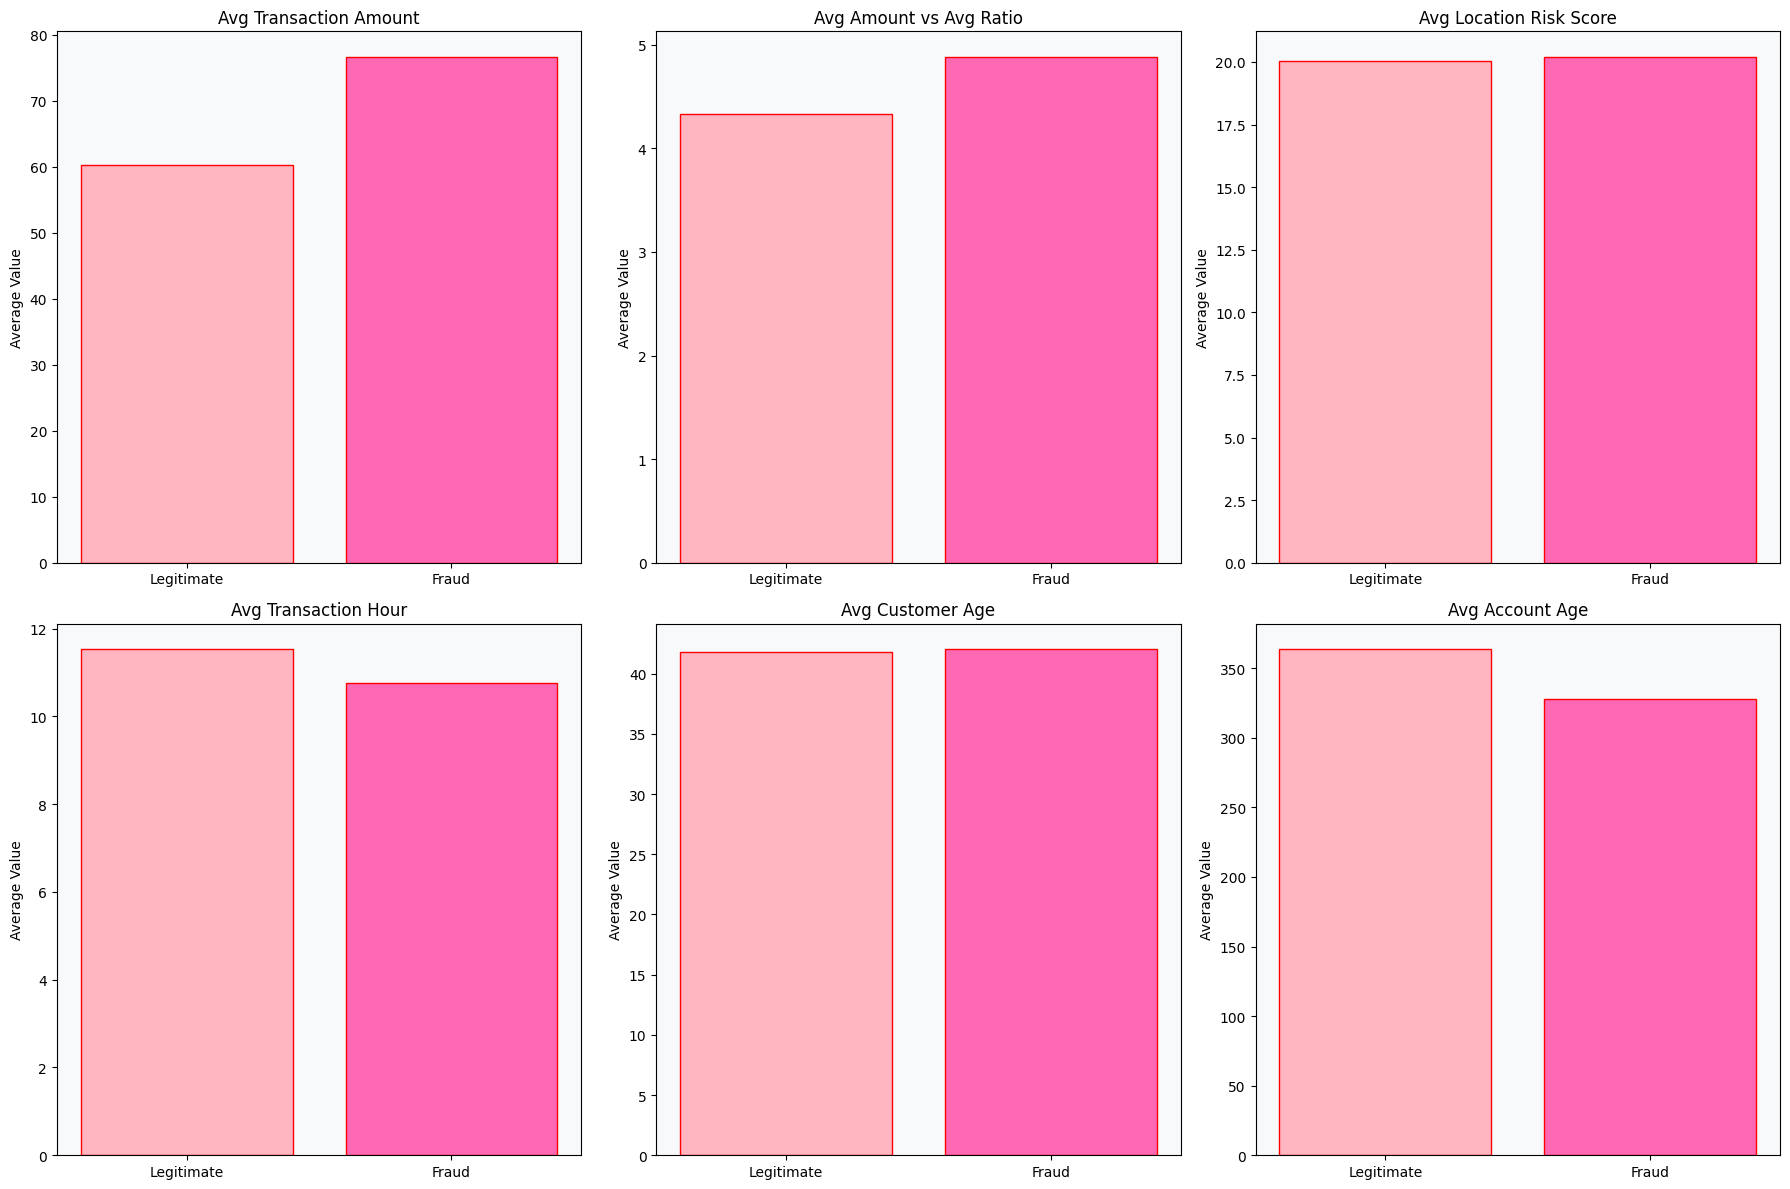

In [7]:
#Using means to display better visuals

fraud_means = data3.groupby('is_fraud')[
    ['transaction_amount', 'amount_vs_average_ratio', 'location_risk_score']
].mean()

print(fraud_means)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Function to make bar plots easily
def plot_mean(feature, ax, title):
    means = data3.groupby('is_fraud')[feature].mean()

    ax.bar(
        ['Legitimate', 'Fraud'],
        means.values,
        color=["#ffb6c1", "#ff69b4"],
        edgecolor="red"
    )

    ax.set_title(title)
    ax.set_ylabel("Average Value")

# 1. Transaction Amount
plot_mean('transaction_amount', axes[0, 0], 'Avg Transaction Amount')

# 2. Amount vs Average Ratio
plot_mean('amount_vs_average_ratio', axes[0, 1], 'Avg Amount vs Avg Ratio')

# 3. Location Risk Score
plot_mean('location_risk_score', axes[0, 2], 'Avg Location Risk Score')

# 4. Transaction Hour
plot_mean('transaction_hour', axes[1, 0], 'Avg Transaction Hour')

# 5. Customer Age
plot_mean('customer_age', axes[1, 1], 'Avg Customer Age')

# 6. Account Age
plot_mean('account_age_days', axes[1, 2], 'Avg Account Age')

plt.tight_layout()
plt.show()

3. Accuracy is not a suitable metric for fraud detection because the dataset is highly imbalanced, only a very small proportion of transactions are fraudulent. As shown in the visualizations above, fraud makes up such a small percent of the data. An attempt to use means to achieve a better visualization showed very little difference. Due to this, a model can achieve very high accuracy by simply predicting all transactions as legitimate, while failing to identify actual fraud cases. This makes accuracy misleading and not reflective of true model performance. Instead, metrics such as recall, precision, and F1-score are more appropriate for evaluating fraud detection models.

# **Part B: Model Training**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features and target
features = [
    'transaction_amount', 'merchant_category', 'transaction_hour', 'day_of_week',
    'is_weekend', 'customer_age', 'account_age_days',
    'previous_transactions_day', 'average_transaction_amount', 'credit_limit',
    'amount_vs_average_ratio', 'time_since_last_transaction',
    'location_risk_score'
]

X = data3[features]
y = data3['is_fraud']

# Split the data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale for Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature names: {features}")

Training set size: 40000
Test set size: 10000
Feature names: ['transaction_amount', 'merchant_category', 'transaction_hour', 'day_of_week', 'is_weekend', 'customer_age', 'account_age_days', 'previous_transactions_day', 'average_transaction_amount', 'credit_limit', 'amount_vs_average_ratio', 'time_since_last_transaction', 'location_risk_score']


First the target variable is defined (fraud). The data is then split so the model can be trained. Features are then scaled to be in the same measurements, this is so difference in value measures are not drastic. Then, the training/test size, feature names and number of features are printed to verify accuracy.

**Logistic Regression**

In [9]:
# Train Logistic Regression model
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Scale the features
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Logistic Regression Results:
Accuracy: 0.6268
Precision: 0.0027
Recall: 0.3333
F1-Score: 0.0053
AUC-ROC: 0.4706


This code first trains the model using the scaled data and then predictions are made on the test set. To evaluate the model; accuracy, precision, recall, F!-score and AUC-ROC were used to assess overall performance.

These results indicate that Logistic Regression is performing very poorly, especially in terms of precision and overall predictive power. The extremely low precision (0.0027) and F1-score (0.0053) suggest that most positive predictions are incorrect, even though recall (33.33%) shows it is identifying some positive cases. Additionally, the AUC (0.4706) is below 0.5, meaning the model is performing worse than random guessing, making it unreliable for this problem.

**Random Forest:**

In [10]:
from sklearn.ensemble import RandomForestClassifier

#Train Model

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

#Make predictions

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

Random Forest Results:
Accuracy: 0.9970
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC-ROC: 0.4911


This code trains a Random Forest model using balanced class weights to better handle imbalanced data, then makes predictions on the test set. It evaluates performance using key metrics to assess how well the model identifies fraud and generalizes to new data.

The results show extremely high accuracy but fails to identify any fraud cases, as seen by zero precision, recall, and F1-score. This indicates the model is predicting all transactions as legitimate, likely due to class imbalance, and is not effective for detecting fraud despite the high accuracy.

**Support Vector Machine (RBF Kernal):**

In [11]:
# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")
    svm_model = SVC(kernel=kernel, class_weight='balanced', random_state=42, probability=True)
    svm_model.fit(X_train_scaled, y_train)

    y_pred_svm = svm_model.predict(X_test_scaled)
    y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_svm)
    precision = precision_score(y_test, y_pred_svm)
    recall = recall_score(y_test, y_pred_svm)
    f1 = f1_score(y_test, y_pred_svm)
    auc = roc_auc_score(y_test, y_pred_proba_svm)

    svm_results[kernel] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'predictions': y_pred_svm,
        'probabilities': y_pred_proba_svm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")

# Find best kernel
best_kernel = max(svm_results.keys(), key=lambda k: svm_results[k]['f1'])
print(f"\nBest kernel: {best_kernel}")


Training SVM with linear kernel...
Accuracy: 0.7035
F1-Score: 0.0074
AUC-ROC: 0.5118

Training SVM with rbf kernel...
Accuracy: 0.9053
F1-Score: 0.0104
AUC-ROC: 0.4829

Training SVM with poly kernel...
Accuracy: 0.8139
F1-Score: 0.0043
AUC-ROC: 0.4287

Best kernel: rbf


This code trains SVM models with different kernels using balanced class weights to better handle imbalanced data. Each model is evaluated using performance metrics, and the best kernel is selected based on the highest F1-score, which prioritizes detecting the minority (fraud) class.

**Model Evaluation Comparision Table:**

In [13]:
results = []

# Logistic Regression
results.append({
    'Model': 'Logistic Regression',
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'AUC-ROC': roc_auc_score(y_test, y_pred_proba_lr)
})


# SVM
results.append({
    'Model': 'SVM',
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm),
    'AUC-ROC': roc_auc_score(y_test, y_pred_proba_svm)

})

results_df = pd.DataFrame(results)
print(results_df.round(4))

                 Model  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression     0.0027  0.3333    0.0053   0.4706
1                  SVM     0.0022  0.1333    0.0043   0.4287


This code creates a comparison of model performance by storing evaluation metrics for Logistic Regression and SVM in a list of dictionaries. It calculates precision, recall, F1-score, and AUC-ROC for each model to ensure a balanced evaluation, especially important for churn prediction where class imbalance matters. The results are then converted into a DataFrame for easy comparison and cleaner presentation.

**Confusion Matrix for all Models:**

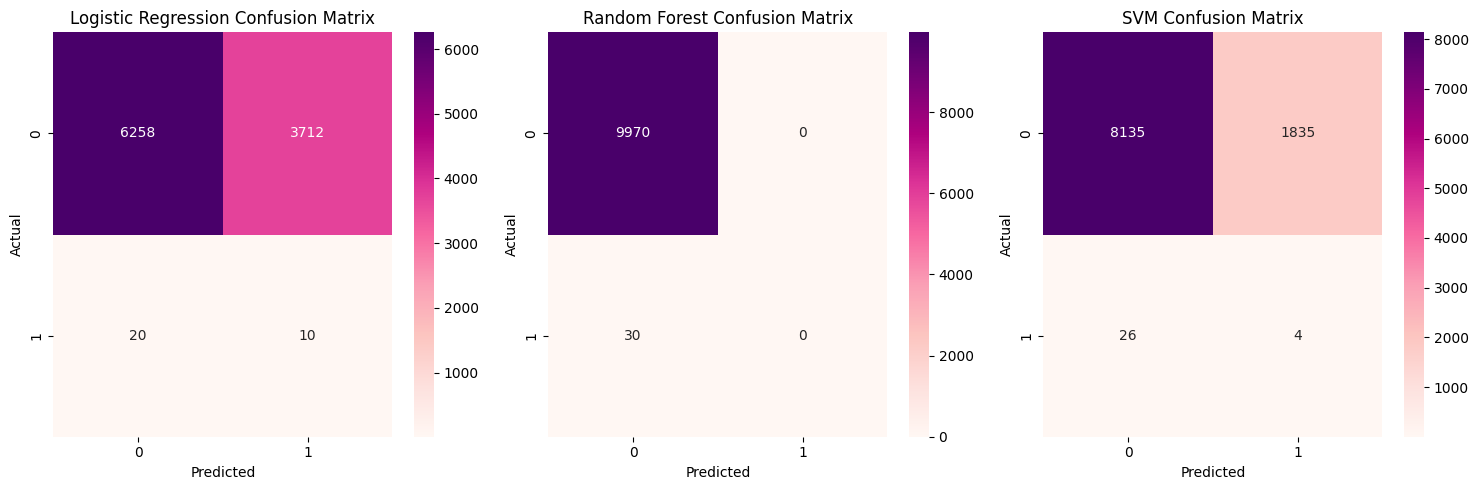

In [14]:
models = {
    'Logistic Regression': (y_pred_lr, None),
    'Random Forest': (y_pred_rf, None),
    'SVM': (y_pred_svm, None)
}


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for i, (model_name, (y_pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='RdPu',
        ax=axes[i]
    )

    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

This code generates confusion matrices for multiple models (Logistic Regression, Random Forest, and SVM) to visually compare their prediction performance. It helps show how well each model correctly classifies fraud vs. legitimate cases, including errors like false positives and false negatives.

# **Part C: Business Impacts**

1. Logistic Regression achieved the highest recall score (33.3%), indicating it was more effective than SVM at identifying fraudulent transactions and minimizing missed fraud cases. However, the relatively low recall highlights the difficulty of detecting rare fraud events within a highly imbalanced dataset.

2. The trade off between catching fraud and false alarms is recall vs. precision. A model that captures more fraudulent transactions (higher recall) will tend to generate more false positives (low precision). On the other hand, reducing false positives may lead to more missed fraud cases. Therefore, a balance between recall and precision must be considered.

3. The Logistic Regression is recommended for production use because it has the highest recall. In case of fraud detection, this is the most important metric.